In [1]:
import json
import csv
import argparse
import os
def parse_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def compare_testsuite_times(json_list, output_csv):

    testsuites_list = [ {suite['name']: suite for suite in json_data['testsuites']} for json_data in json_list]

    all_suite_names = set(testsuites_list[0].keys()).union(set(testsuites_list[1].keys()))
    for i in range(2, len(testsuites_list)):
        all_suite_names.union( set(testsuites_list[i].keys()) )


    test_counts = len(testsuites_list)
    with open(output_csv, 'w', newline='') as csvfile:
        fieldnames = ['suite_name', 'test_name', 'value_param'] + [str(i+1) for i in range(0, test_counts)]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        for suite_name in all_suite_names:

            suite_list = [testsuites.get(suite_name) for testsuites in testsuites_list]

            if not all(suite_list):
                continue

            suite_tests_list = [{test['name']: test for test in suite['testsuite']} for suite in suite_list]

            all_test_names = set(suite_tests_list[0].keys()).union(set(suite_tests_list[1].keys()))
            for i in range(2, len(suite_tests_list)):
                all_test_names.union( set(suite_tests_list[i].keys()) )


            # suite_tests_list: N
            for test_name in all_test_names:

                # 检查测试名称是否都在json文件中被包含
                skip_flag = False
                fail_match_index_list = []
                for kk, _test in enumerate(suite_tests_list):
                    _test_item = _test.get(test_name, False)
                    if not _test_item:
                        fail_match_index_list.append(kk)
                        skip_flag = True
                if skip_flag == True:
                    print(f'命中测试名：{test_name}存在失败，将跳过, 失败的索引为 {fail_match_index_list} ')
                    continue

                # 检查测试参数是否一致
                skip_flag_list = []
                for kk, _test in enumerate(suite_tests_list):
                    _test_item = _test.get(test_name)
                    _value_param = _test_item.get('value_param', False)
                    skip_flag_list.append(_value_param)
                if len(set(skip_flag_list)) != 1:
                    print(f'{test_name}匹配参数列表失败，将跳过，列表为{skip_flag_list}')
                    continue

                value_param = suite_tests_list[0].get(test_name).get('value_param', '0')
                init_dict = {'suite_name': suite_name, 'test_name': test_name, 'value_param': value_param}

                for j in range(0, test_counts):
                    name_index = str(j+1)
                    current_test = suite_tests_list[j].get(test_name)
                    current_time = current_test.get('mean', '0')
                    init_dict[name_index] = current_time

                writer.writerow(init_dict)

In [2]:
# os.listdir('./results_k1_yrvv_all')

In [2]:
current_index = 0

save_dir_list = ['./compare_core', './compare_imgproc', './compare_calib3d', './compare_features2d']
csv_file_name_list = ['compare_core', 'compare_imgproc', 'compare_calib3d', 'compare_features2d']

# dir
save_dir = save_dir_list[current_index]
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# csv file path
csv_file_name = csv_file_name_list[current_index]
save_csv_path = os.path.join(save_dir, csv_file_name+'.csv')

# perf file
base_path_list = ['./results_k1_yrvv_all', './results_k1_nrvv_all', './results_3568_all', './results_3568_nneno_all']
json_file_name_list = ['opencv_core.json', 'opencv_imgproc.json', 'opencv_calib3d.json', 'opencv_features2d.json']

base_json_list = []
for path_ in base_path_list:
    full_path_ = os.path.join(path_, json_file_name_list[current_index])
    base_json_list.append(full_path_)

json_list = []
for item in base_json_list:
    json_list.append(parse_json_file(item))

compare_testsuite_times(json_list, save_csv_path)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


# 读取 CSV 文件
csv_file = save_csv_path
df = pd.read_csv(csv_file)

# 定义要替换的列索引和列表
columns_to_replace = [3, 4, 5, 6]  # 需要替换内容的列索引（从 0 开始）
title = ['k1 RVV', 'k1 No RVV', '3568 NENO', '3568 NO NENO']


# 替换标题栏的列名
for idx, col in enumerate(df.columns):
    if idx in columns_to_replace:
        df.columns.values[idx] = title[idx-3]


df[''] = None  # 或者可以用 "" 创建一个空字符串列

# 计算第四列（索引为3）减去第三列（索引为2），并将结果添加为第九列（新列）
df['RVV VS NO RVV'] = 100 * (df.iloc[:, 4] - df.iloc[:, 3])/df.iloc[:, 4]

df['k1 RVV VS 3568 NENO'] = 100 * (df.iloc[:, 5] - df.iloc[:, 3])/df.iloc[:, 5]

df['NO RVV VS 3568 NO NENO'] = 100 * (df.iloc[:, 6] - df.iloc[:, 4])/df.iloc[:, 6]

df['NENO VS NO NENO'] = 100 * (df.iloc[:, 6] - df.iloc[:, 5])/df.iloc[:, 6]


# 将 DataFrame 写入 XLSX 文件
xlsx_file = os.path.join(save_dir, csv_file_name+'.xlsx')
df.to_excel(xlsx_file, index=False, engine='openpyxl')

print(f"成功将 '{csv_file}' 转换为 '{xlsx_file}'")


成功将 './compare_core/compare_core.csv' 转换为 './compare_core/compare_core.xlsx'


In [4]:
row = 2
col = 2
col_name_list = ['RVV VS NO RVV', 'k1 RVV VS 3568 NENO', 'NO RVV VS 3568 NO NENO', 'NENO VS NO NENO']

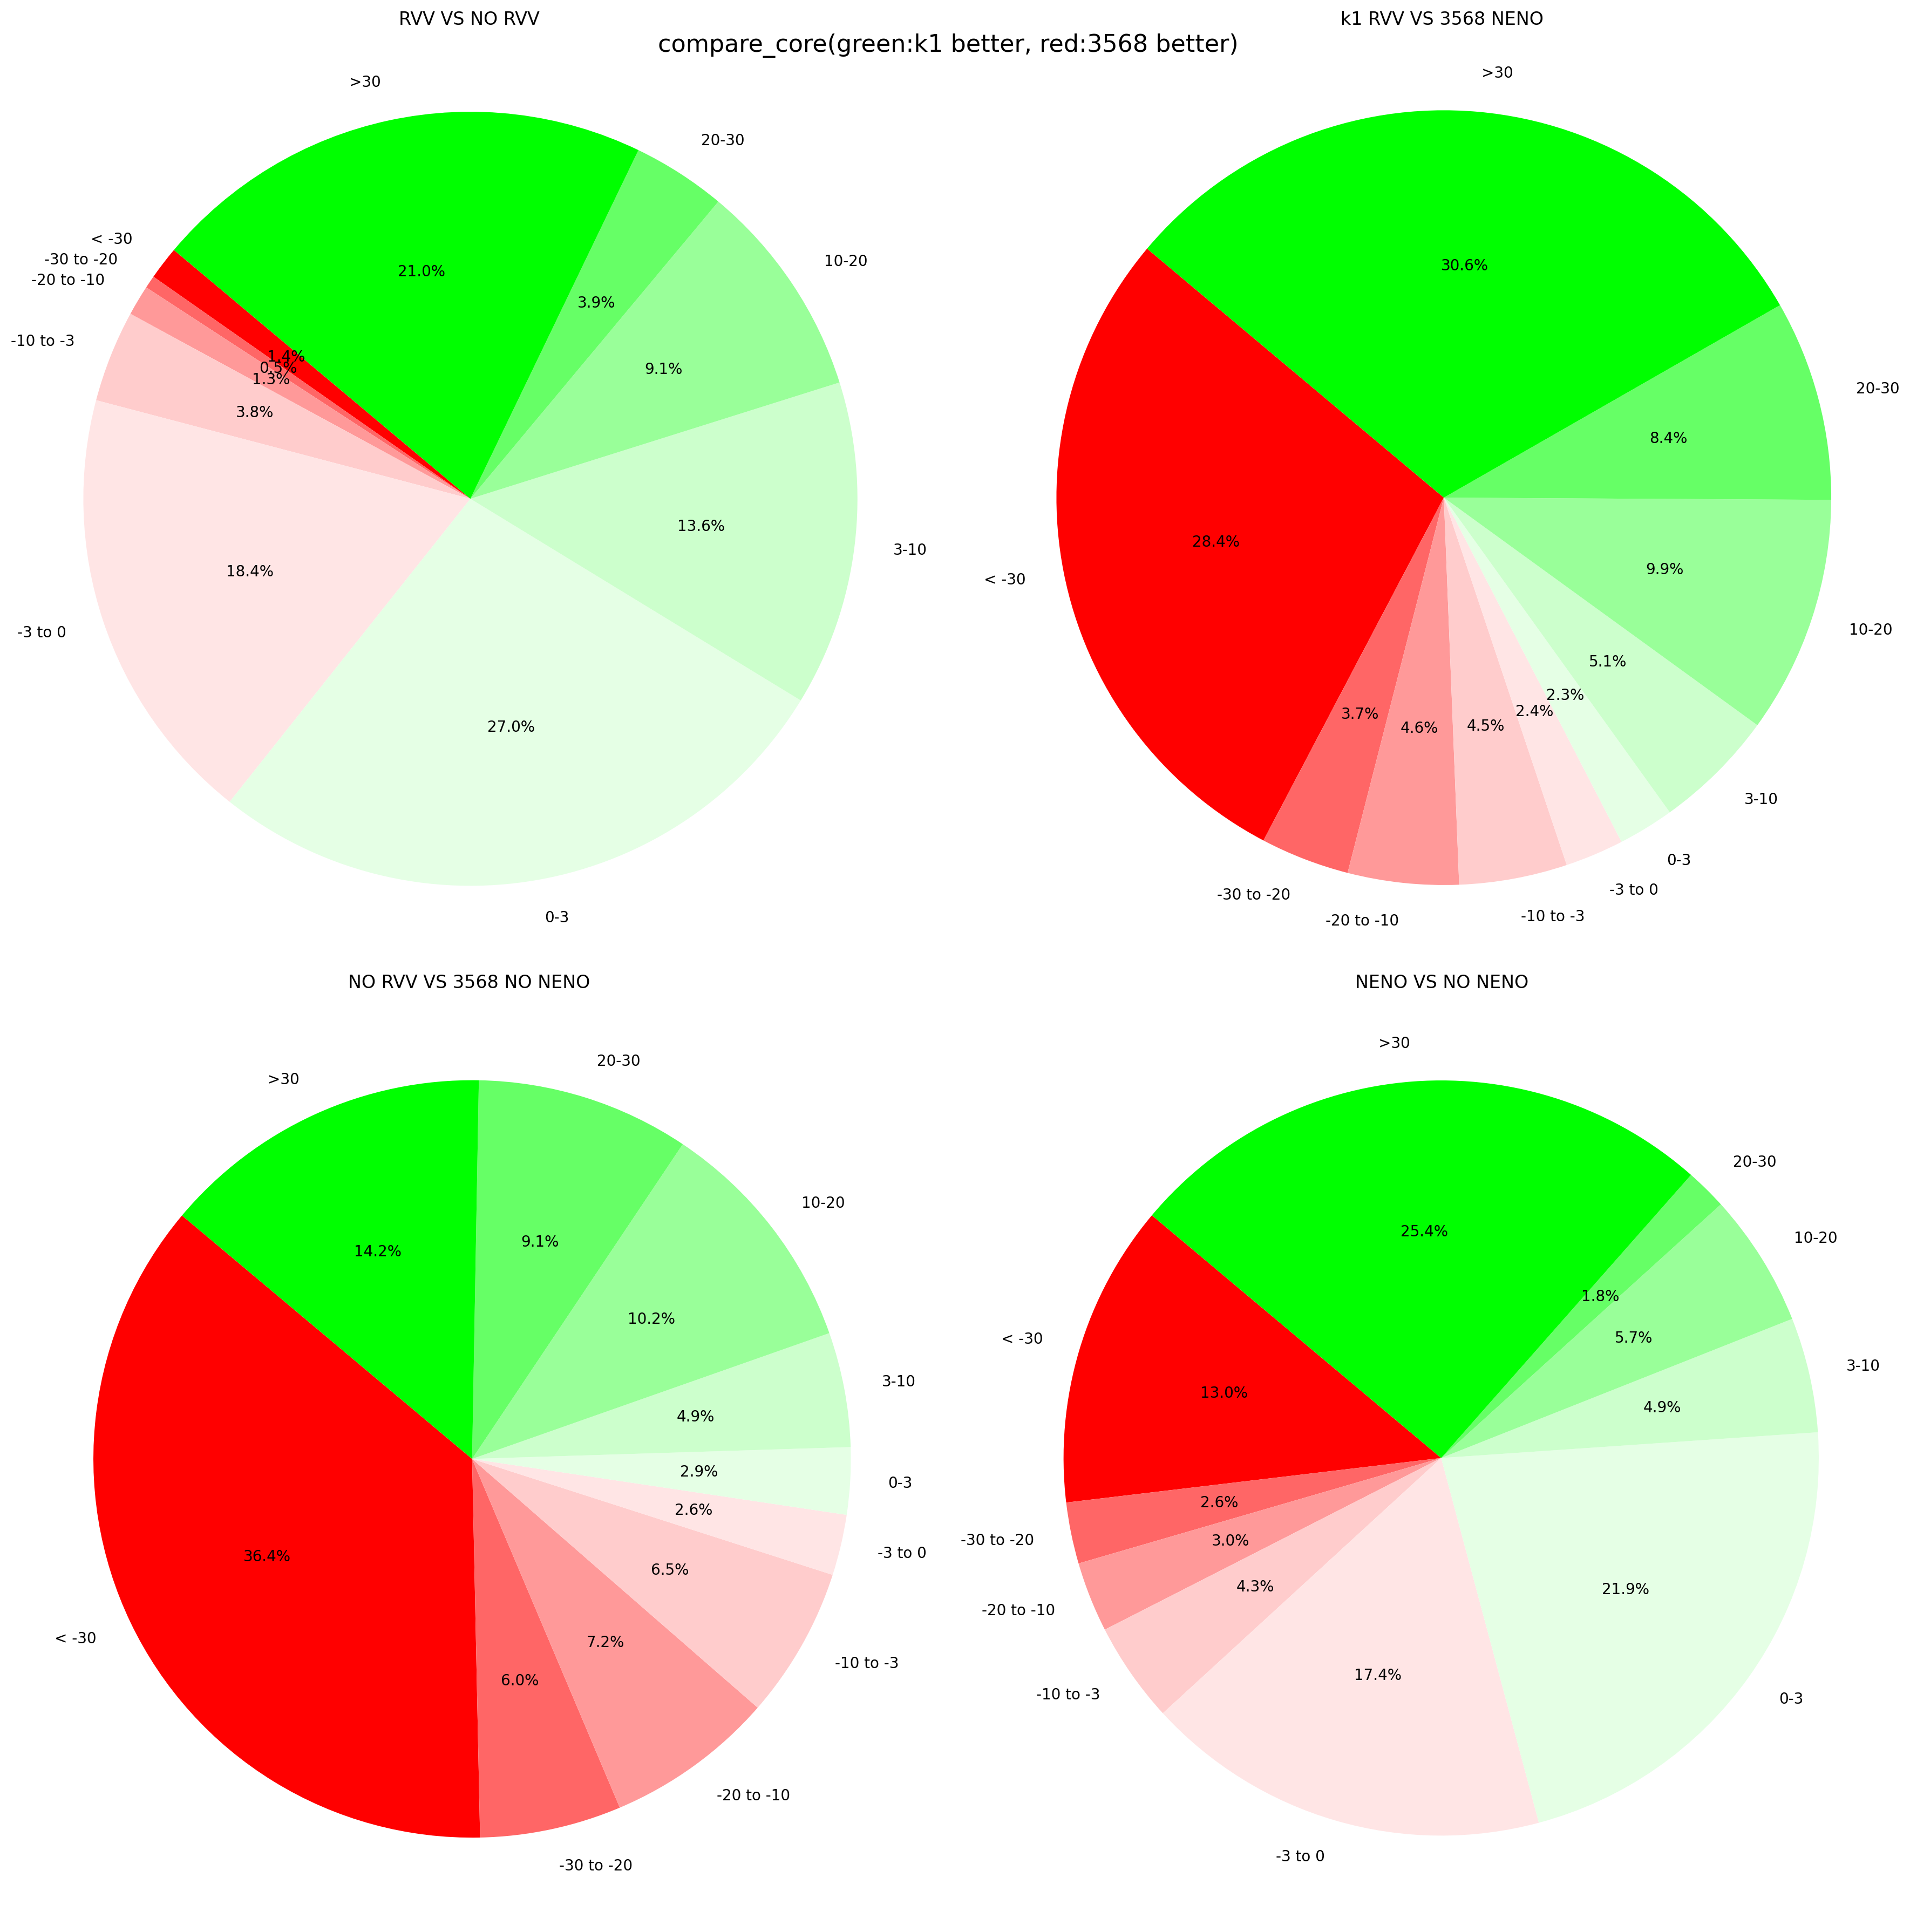

In [5]:
import matplotlib.pyplot as plt
# 设置饼状图的值区间及对应颜色
def categorize(value):
    if value <= -30:
        return '< -30'
    elif -30 < value <= -20:
        return '-30 to -20'
    elif -20 < value <= -10:
        return '-20 to -10'
    elif -10 < value <= -3:
        return '-10 to -3'
    elif -3 < value < 0:
        return '-3 to 0'
    elif 0 <= value < 3:
        return '0-3'
    elif 3 <= value < 10:
        return '3-10'
    elif 10 <= value < 20:
        return '10-20'
    elif 20 <= value < 30:
        return '20-30'
    else:
        return '>30'

colors = ['#FF0000', '#FF6666', '#FF9999', '#FFCCCC','#FFE5E5',   '#E5FFE5', '#CCFFCC', '#99FF99', '#66FF66', '#00FF00']

desired_order = ['< -30', '-30 to -20', '-20 to -10', '-10 to -3','-3 to 0',    '0-3', '3-10', '10-20', '20-30', '>30']

row = 2
col = 2
plt.figure(figsize=(18, 18), dpi=200)
for _i, _name in enumerate(col_name_list):
    category_counts1 = df[_name].apply(categorize).value_counts()
    category_counts1 = category_counts1.reindex(desired_order, fill_value=0)
    # 创建饼状图
    plt.subplot(row, col, _i+1)
    plt.pie(category_counts1, labels=category_counts1.index, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.title(_name)
    plt.axis('equal')  # 使饼状图为正圆
    plt.tight_layout()


# 调整子图之间的间距
plt.subplots_adjust(wspace=5)  # wspace控制子图之间的宽度
plt.tight_layout()
plt.suptitle(f'{csv_file_name}(green:k1 better, red:3568 better)', fontsize=16)  # 可以设置字体大小和其他参数


img_file = os.path.join(save_dir, csv_file_name + '_pie.png')
plt.savefig(img_file, dpi=200, bbox_inches='tight')  # 保存为 PNG 文件，边界紧凑
plt.show()

In [6]:
# 数据分离 按照饼状图分区
# 需要保存的目标列名（在这些列上应用区间分类）
col_name_list = ['RVV VS NO RVV', 'k1 RVV VS 3568 NENO', 'NO RVV VS 3568 NO NENO', 'NENO VS NO NENO']

# 遍历每个目标列
for col in col_name_list:
    # 保留所有列，排除指定的列
    columns_to_exclude = col_name_list.copy()
    columns_to_exclude.remove(col)

    # 获取区间标记
    category_series = df[col].apply(categorize)

    # 遍历每个区间，提取对应的数据行并保存到新的 CSV 中
    for category in category_series.unique():
        filtered_data = df[category_series == category]

        if not filtered_data.empty:

            cols_to_keep = [c for c in df.columns if c not in columns_to_exclude or c == col]
            filtered_data = filtered_data[cols_to_keep]
            # 确定保存的文件路径和文件名
            folder_name = os.path.join(save_dir, '饼状图区间分离数据', col.replace(' ', '_'))
            os.makedirs(folder_name, exist_ok=True)

            # csv_output_file = os.path.join(folder_name, f"{csv_file_name}_{col.replace(' ', '_')}_{category.replace(' ', '_').replace('<', 'lt').replace('>', 'gt')}.csv")
            # filtered_data.to_csv(csv_output_file, index=False)

            # 将 DataFrame 写入 XLSX 文件
            xlsx_output_file = os.path.join(folder_name, f"{csv_file_name}_{col.replace(' ', '_')}_{category.replace(' ', '_').replace('<', 'lt').replace('>', 'gt')}.xlsx")
            filtered_data.to_excel(xlsx_output_file, index=False, engine='openpyxl')

            # print(f"数据已保存在文件 '{xlsx_output_file}'")

In [7]:
def categorize_binary(value):
    if value < 0:
        return '< 0'
    else:
        return '>0'

# 数据分离 按照饼状图分区
# 需要保存的目标列名（在这些列上应用区间分类）
col_name_list = ['RVV VS NO RVV', 'k1 RVV VS 3568 NENO', 'NO RVV VS 3568 NO NENO', 'NENO VS NO NENO']

# 遍历每个目标列
for col in col_name_list:
    # 保留所有列，排除指定的列
    columns_to_exclude = col_name_list.copy()
    columns_to_exclude.remove(col)

    # 获取区间标记
    category_series = df[col].apply(categorize_binary)

    # 遍历每个区间，提取对应的数据行并保存到新的 CSV 中
    for category in category_series.unique():
        filtered_data = df[category_series == category]

        if not filtered_data.empty:

            cols_to_keep = [c for c in df.columns if c not in columns_to_exclude or c == col]
            filtered_data = filtered_data[cols_to_keep]
            # 确定保存的文件路径和文件名
            folder_name = os.path.join(save_dir, '0分界线分离数据', col.replace(' ', '_'))
            os.makedirs(folder_name, exist_ok=True)

            # 将 DataFrame 写入 XLSX 文件
            xlsx_output_file = os.path.join(folder_name, f"{csv_file_name}_{col.replace(' ', '_')}_{category.replace(' ', '_').replace('<', 'lt').replace('>', 'gt')}.xlsx")
            filtered_data.to_excel(xlsx_output_file, index=False, engine='openpyxl')


In [8]:

# 使用 pd.cut 划分区间
bins = [-400,-100,-50,-30, -20, -15, -10, -5, -2, -1,-0.5,-0.1, 0, 0.1,0.5, 1, 2, 5, 10, 15, 20, 30, 50, 100, 400]  # 创建区间 [1, 2, 3, ..., 11]
labels = [f"{bins[i]}\nto\n{bins[i+1]}" for i in range(0, len(bins)-1)]  # 创建标签 "1-2", "2-3", ..., "10-11"


plt.figure(figsize=(15, 10), dpi=200)
for _i, _name in enumerate(col_name_list):

    # 将值转换为区间
    binned = pd.cut(df[_name], bins=bins, right=False, labels=labels)
    # 计算每个区间的频数
    histogram = binned.value_counts().sort_index()

    # 绘制柱状图
    plt.subplot(row, col, _i+1)
    bars = histogram.plot(kind='bar', color='skyblue')  # 使用绘图方法绘制柱状图
    # 在每个柱子顶部显示计数
    for bar in bars.patches:
        plt.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                int(bar.get_height()),
                ha='center', va='bottom')  # 计数居中显示在柱子顶部

    plt.title(f'{_name} Frequency')  # 设置标题
    plt.xlabel(_name)  # 设置 x 轴标签
    plt.ylabel('Frequency')  # 设置 y 轴标签
    plt.xticks(rotation=0)  # 旋转 x 轴标签，便于查看
    plt.tight_layout()  # 自动调整子图参数，以给坐标轴标签留出空间

    # 显示图形
plt.show()

ValueError: Number of columns must be a positive integer, not 'NENO VS NO NENO'

<Figure size 3000x2000 with 0 Axes>